# ML Journal — Notes

Running notebook for courses, papers, and experiments.

## Imports

In [3]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 22.6 MB/s eta 0:00:0031m25.9 MB/s eta 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.3.4_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

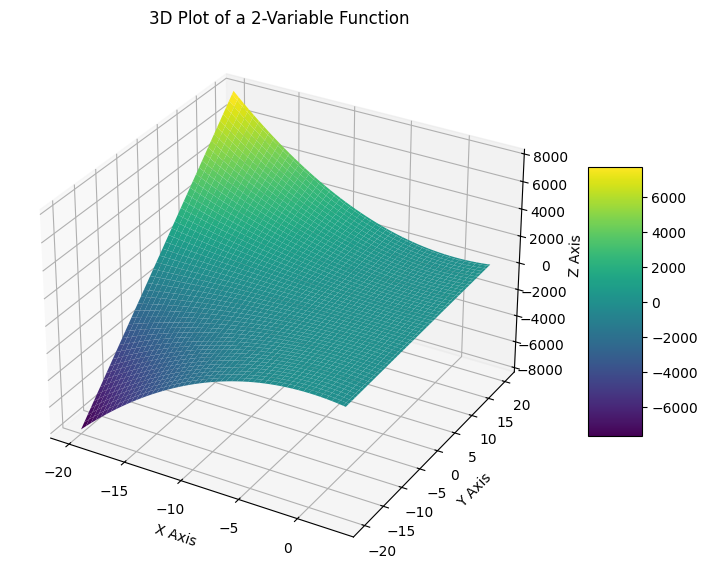

In [35]:
X = np.linspace(-20, 3, 100)
Y = np.linspace(-20, 20, 100)
X, Y = np.meshgrid(X, Y)
f = X**2 * Y

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(X, Y, f, cmap='viridis', edgecolor='none')

ax.set_title("3D Plot of a 2-Variable Function")
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
fig.colorbar(surface, shrink=0.5, aspect=5)  # Adds a visual scale

plt.show()

## Calculus

In [14]:
%pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 6.4 MB/s eta 0:00:00m eta 0:00:010:01:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 11.1 MB/s eta 0:00:0031m11.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 9.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.3.4_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
import torch

def compute_gradient(math_fn, inputs_dict):
    """
    Computes the gradient/Jacobian of a mathematical function at given input points.
    
    Parameters:
    - math_fn: A Python function representing your formula.
    - inputs_dict: A dictionary of {'variable_name': float_value}
    """
    # 1. Convert inputs to PyTorch tensors and enable gradient tracking
    tensors = {k: torch.tensor([float(v)], requires_grad=True) for k, v in inputs_dict.items()}
    
    # 2. Wrapper function because PyTorch expects a tuple/list of inputs positional arguments
    def wrapper(*args):
        # Map the positional args back to their variable names for your math formula
        named_args = {name: arg for name, arg in zip(tensors.keys(), args)}
        return math_fn(named_args)
    
    # 3. Extract the raw tensors in order to feed into PyTorch
    input_tensors = tuple(tensors.values())
    
    # 4. Compute the output of your math function
    output = math_fn(tensors)
    
    # 5. Trigger backpropagation to compute gradients
    output.backward()
    
    # 6. Extract the calculated gradients for each variable
    gradients = {name: tensor.grad.item() for name, tensor in tensors.items()}
    
    return output.item(), gradients

In [23]:
import numpy as np

# Example 1: Test with y = sin(x) * sin(z)
# Our function expects a dictionary of inputs
my_formula = lambda v: torch.exp(v['x']) * torch.exp(v['z']) * torch.sin(v['y'])
my_formula1 = lambda v: torch.exp(v['x']) * torch.exp(v['z']) * torch.sin(v['y'])
# Set the evaluation points: x = pi/4, z = pi/2
points = {'x': np.pi / 4, 'z': np.pi / 2, 'y': np.pi / 2}

# Run the generic differentiator
value, grads = compute_gradient(my_formula, points)

print(f"Function Output: {value}")
print(f"Gradients: {grads}")

Function Output: 10.550725936889648
Gradients: {'x': 10.550725936889648, 'z': 10.550725936889648, 'y': -4.611868860138202e-07}


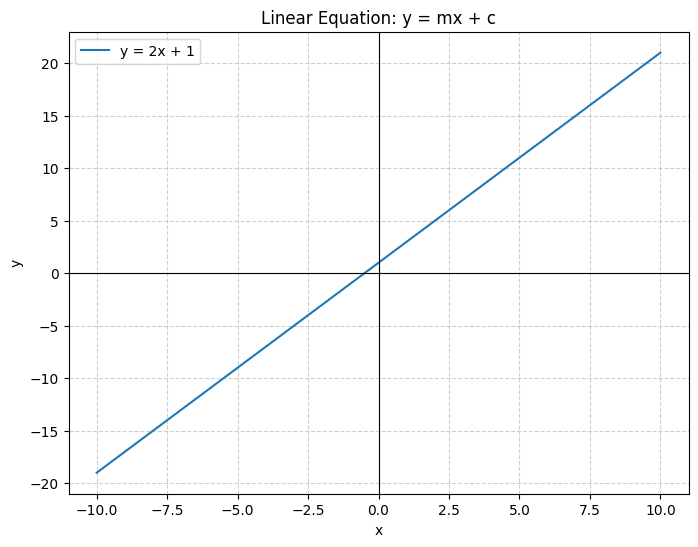

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Define slope and intercept
m = 2      # slope
c = 1      # y-intercept

# Generate x values
x = np.linspace(-10, 10, 100)

# Calculate y
y = m * x + c

# Plot
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=f'y = {m}x + {c}')
plt.axhline(0, color='black', linewidth=0.8)   # x-axis
plt.axvline(0, color='black', linewidth=0.8)   # y-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Linear Equation: y = mx + c')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()